In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import VotingClassifier, VotingRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
CV_FOLDS = 5

In [ ]:
def evaluate_models_cv(models: dict, X, y, cv=CV_FOLDS, scoring="accuracy"):
    """Cross-validate every model in `models` and print mean +/- std."""
    results = {}
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
        results[name] = scores
        print(f"  {name:24s} | CV {scoring:6s}: {scores.mean():.4f} +/- {scores.std():.4f}")
    return results


def plot_classification_overlay(models: dict, X, y, title, filename, ensemble_name):
    """
    One figure: the ensemble's decision region is filled in the background,
    every individual model's decision *boundary* is drawn as a colored
    contour line on top. Data points are scattered over everything.
    """
    h = 0.03
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(models) - 1, 1)))

    color_i = 0
    for name, model in models.items():
        model.fit(X, y)
        Z = model.predict(grid).reshape(xx.shape)
        if name == ensemble_name:
            ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm, zorder=0)
            ax.contour(xx, yy, Z, colors="black", linewidths=2.5, levels=[0.5], zorder=4)
        else:
            ax.contour(xx, yy, Z, colors=[colors[color_i]], linewidths=1.4,
                       levels=[0.5], linestyles="--", zorder=3)
            color_i += 1

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k", s=25, zorder=5)

    color_i = 0
    handles = []
    for name in models:
        if name == ensemble_name:
            continue
        handles.append(plt.Line2D([0], [0], color=colors[color_i], lw=2, ls="--", label=name))
        color_i += 1
    handles.append(plt.Line2D([0], [0], color="black", lw=2.5, label=f"{ensemble_name} (filled region)"))

    ax.legend(handles=handles, loc="best", fontsize=8, framealpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    plt.tight_layout()
    plt.show(fig)


def plot_regression_lines(models: dict, X, y, title, filename, ensemble_name):
    """Scatter the 1-D data, draw every model's prediction curve, ensemble bold on top."""
    x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 400).reshape(-1, 1)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(X, y, color="gray", alpha=0.35, s=20, label="data", zorder=1)

    colors = plt.cm.tab10(np.linspace(0, 1, max(len(models) - 1, 1)))
    color_i = 0
    for name, model in models.items():
        model.fit(X, y)
        y_line = model.predict(x_line)
        if name == ensemble_name:
            ax.plot(x_line, y_line, color="black", linewidth=3, label=name, zorder=5)
        else:
            ax.plot(x_line, y_line, color=colors[color_i], linewidth=1.6,
                    linestyle="--", label=name, zorder=3)
            color_i += 1

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("y")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show(fig)

# `Voting Classifier`

### In this type multiple different/same (with different parameters) classification model are grouped together to build one big model that has higher Accuracy then individual models.

## Two types of voting are there:
1. Hard Voting - majority class will be the final output.
2. Soft Voting - Avg. of the probability of each class will be calculated and the class with the highest prob. will be the output.


--- Scenario 1: DIFFERENT base models (LogReg + Tree + KNN) ---
  LogisticRegression       | CV accuracy: 0.8800 +/- 0.0444
  DecisionTree(d=4)        | CV accuracy: 0.8375 +/- 0.0250
  KNN(k=7)                 | CV accuracy: 0.8775 +/- 0.0289
  Voting-DiffModels        | CV accuracy: 0.8625 +/- 0.0335


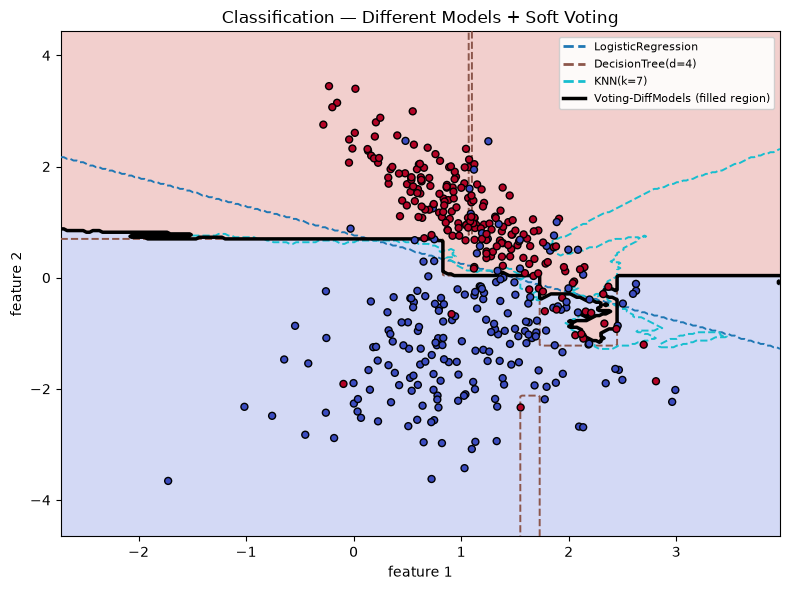

In [ ]:

Xc, yc = make_classification(
    n_samples=400, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.1, flip_y=0.05,
    random_state=RANDOM_STATE,
)

# different base models
print("\n--- Scenario 1: DIFFERENT base models (LogReg + Tree + KNN) ---")
lr = LogisticRegression(random_state=RANDOM_STATE)
dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
knn = KNeighborsClassifier(n_neighbors=7)

vote_diff = VotingClassifier(
    estimators=[("lr", lr), ("dt", dt), ("knn", knn)], voting="soft"
)

models_c1 = {
    "LogisticRegression": lr,
    "DecisionTree(d=4)": dt,
    "KNN(k=7)": knn,
    "Voting-DiffModels": vote_diff,
}
evaluate_models_cv(models_c1, Xc, yc, scoring="accuracy")
plot_classification_overlay(
    models_c1, Xc, yc,
    "Classification — Different Models + Soft Voting",
    "clf_1_different_models.png", "Voting-DiffModels",
)


--- Scenario 2: SAME model (Decision Tree), different depths ---
  Tree(depth=2)            | CV accuracy: 0.8525 +/- 0.0443
  Tree(depth=5)            | CV accuracy: 0.8350 +/- 0.0289
  Tree(depth=None)         | CV accuracy: 0.8450 +/- 0.0245
  Voting-SameModel         | CV accuracy: 0.8500 +/- 0.0316


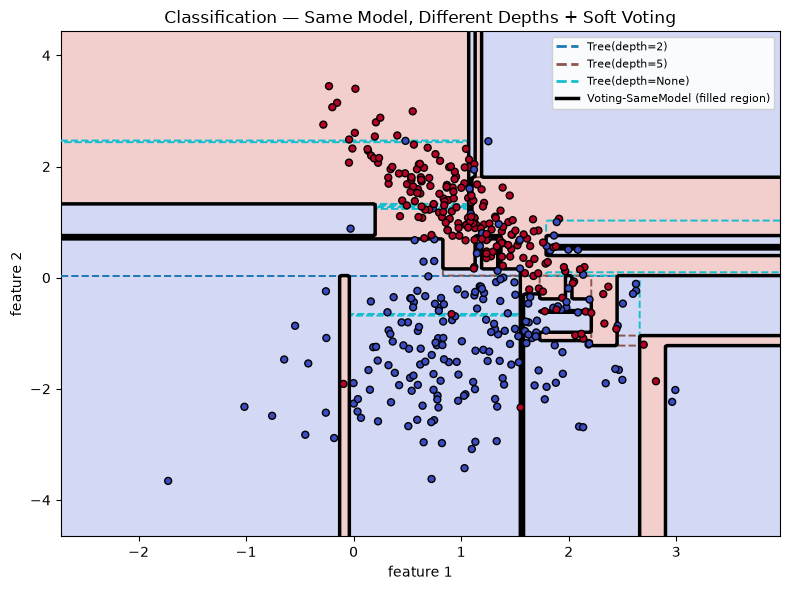

In [ ]:
# same model, different params 
print("\n--- Scenario 2: SAME model (Decision Tree), different depths ---")
dt_shallow = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
dt_medium = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_deep = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)

vote_same = VotingClassifier(
    estimators=[("dt_shallow", dt_shallow), ("dt_medium", dt_medium), ("dt_deep", dt_deep)],
    voting="soft",
)

models_c2 = {
    "Tree(depth=2)": dt_shallow,
    "Tree(depth=5)": dt_medium,
    "Tree(depth=None)": dt_deep,
    "Voting-SameModel": vote_same,
}
evaluate_models_cv(models_c2, Xc, yc, scoring="accuracy")
plot_classification_overlay(
    models_c2, Xc, yc,
    "Classification — Same Model, Different Depths + Soft Voting",
    "clf_2_same_model_diff_params.png", "Voting-SameModel",
)


--- Scenario 3: WEIGHTED voting (weights=[1, 2, 3]) ---
  LogisticRegression       | CV accuracy: 0.8800 +/- 0.0444
  DecisionTree(d=4)        | CV accuracy: 0.8375 +/- 0.0250
  KNN(k=7)                 | CV accuracy: 0.8775 +/- 0.0289
  Voting-Weighted[1,2,3]   | CV accuracy: 0.8575 +/- 0.0281


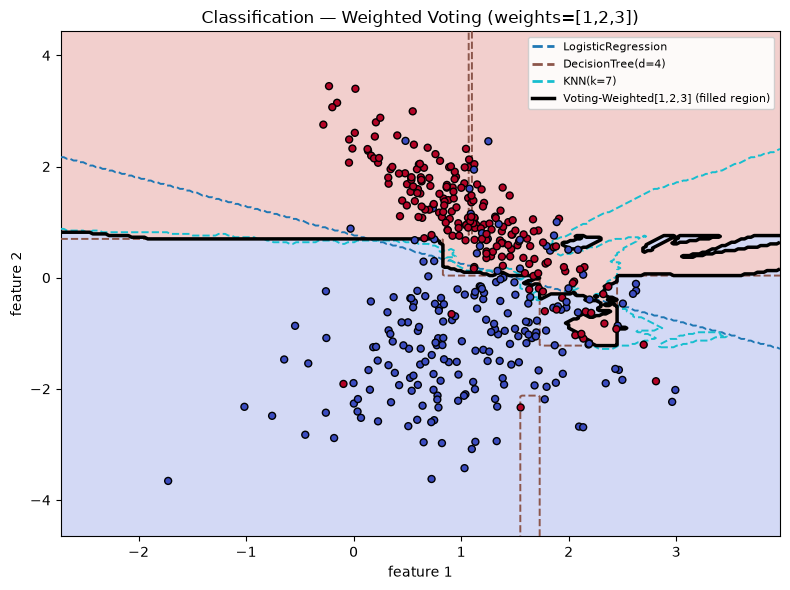

In [ ]:
# manually assigned weights 
print("\n--- Scenario 3: WEIGHTED voting (weights=[1, 2, 3]) ---")
lr_w = LogisticRegression(random_state=RANDOM_STATE)
dt_w = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
knn_w = KNeighborsClassifier(n_neighbors=7)

vote_weighted = VotingClassifier(
    estimators=[("lr", lr_w), ("dt", dt_w), ("knn", knn_w)],
    voting="soft", weights=[1, 2, 3],
)

models_c3 = {
    "LogisticRegression": lr_w,
    "DecisionTree(d=4)": dt_w,
    "KNN(k=7)": knn_w,
    "Voting-Weighted[1,2,3]": vote_weighted,
}
evaluate_models_cv(models_c3, Xc, yc, scoring="accuracy")
plot_classification_overlay(
    models_c3, Xc, yc,
    "Classification — Weighted Voting (weights=[1,2,3])",
    "clf_3_weighted.png", "Voting-Weighted[1,2,3]",
)

# `Voting Regressor`

### In this type multiple different/same (with different parameters) regression model are grouped together to build one big model that has higher Accuracy then individual models.

### The final output will be the Average of all models output. We can also assign the weight to the models so Weighted Average will be the final prediction.


--- Scenario 1: DIFFERENT base models (LinReg + Tree + KNN) ---
  LinearRegression         | CV r2    : 0.6778 +/- 0.0458
  DecisionTree(d=4)        | CV r2    : 0.6230 +/- 0.0390
  KNN(k=7)                 | CV r2    : 0.6326 +/- 0.0191
  Voting-DiffModels        | CV r2    : 0.6659 +/- 0.0345


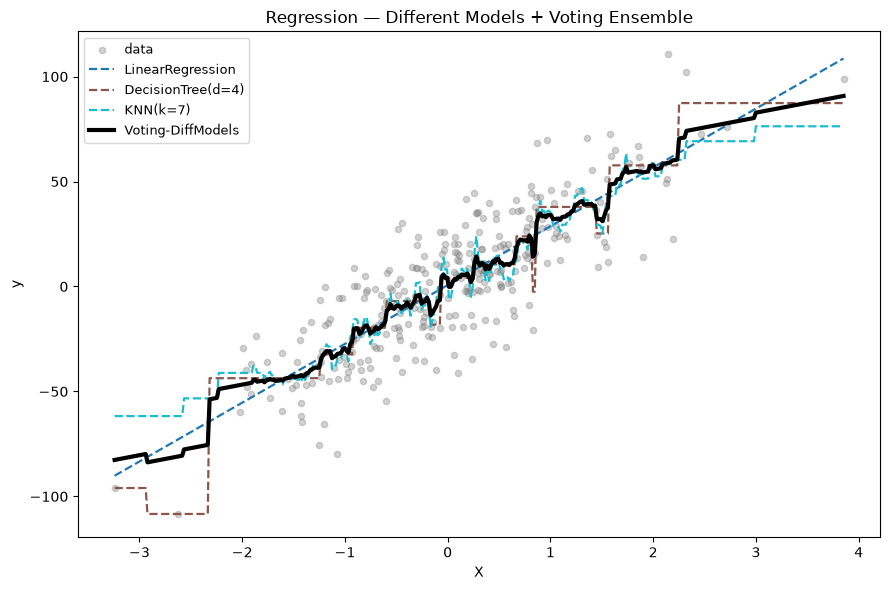

In [ ]:
Xr, yr = make_regression(
    n_samples=300, n_features=1, noise=18, random_state=RANDOM_STATE
)
# add mild nonlinearity so tree/knn models have something to differ on
yr = yr + 0.0025 * (Xr[:, 0] ** 3)

# different base models
print("\n--- Scenario 1: DIFFERENT base models (LinReg + Tree + KNN) ---")
linr = LinearRegression()
dtr = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE)
knnr = KNeighborsRegressor(n_neighbors=7)

vote_reg_diff = VotingRegressor(estimators=[("lr", linr), ("dt", dtr), ("knn", knnr)])

models_r1 = {
    "LinearRegression": linr,
    "DecisionTree(d=4)": dtr,
    "KNN(k=7)": knnr,
    "Voting-DiffModels": vote_reg_diff,
}
evaluate_models_cv(models_r1, Xr, yr, scoring="r2")
plot_regression_lines(
    models_r1, Xr, yr,
    "Regression — Different Models + Voting Ensemble",
    "reg_1_different_models.png", "Voting-DiffModels",
)


--- Scenario 2: SAME model (Decision Tree), different depths ---
  Tree(depth=2)            | CV r2    : 0.6076 +/- 0.0412
  Tree(depth=5)            | CV r2    : 0.6011 +/- 0.0558
  Tree(depth=None)         | CV r2    : 0.3545 +/- 0.1399
  Voting-SameModel         | CV r2    : 0.6039 +/- 0.0517


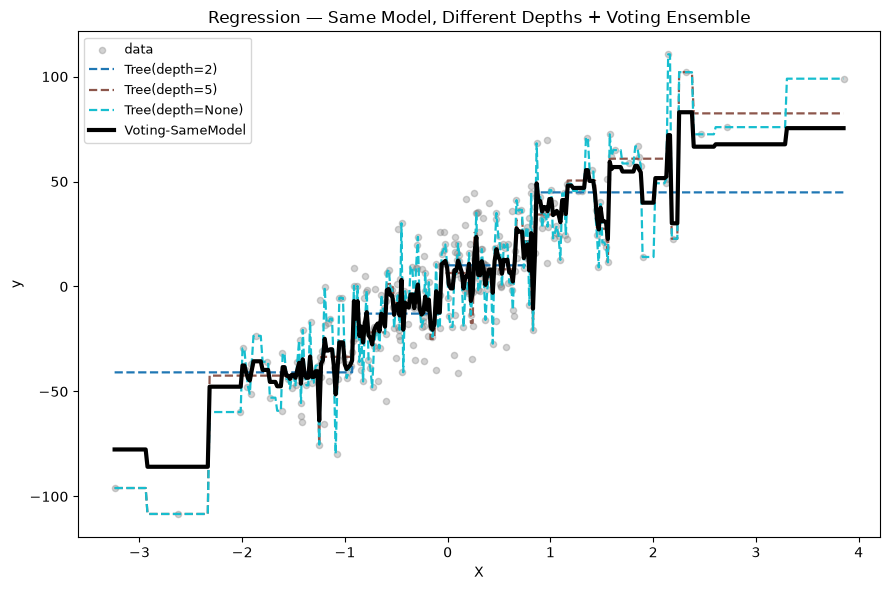

In [ ]:
# same model, different params
print("\n--- Scenario 2: SAME model (Decision Tree), different depths ---")
dtr_shallow = DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE)
dtr_medium = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
dtr_deep = DecisionTreeRegressor(max_depth=None, random_state=RANDOM_STATE)

vote_reg_same = VotingRegressor(
    estimators=[("dt_shallow", dtr_shallow), ("dt_medium", dtr_medium), ("dt_deep", dtr_deep)]
)

models_r2 = {
    "Tree(depth=2)": dtr_shallow,
    "Tree(depth=5)": dtr_medium,
    "Tree(depth=None)": dtr_deep,
    "Voting-SameModel": vote_reg_same,
}
evaluate_models_cv(models_r2, Xr, yr, scoring="r2")
plot_regression_lines(
    models_r2, Xr, yr,
    "Regression — Same Model, Different Depths + Voting Ensemble",
    "reg_2_same_model_diff_params.png", "Voting-SameModel",
)


--- Scenario 3: WEIGHTED voting (weights=[1, 2, 3]) ---
  LinearRegression         | CV r2    : 0.6778 +/- 0.0458
  DecisionTree(d=4)        | CV r2    : 0.6230 +/- 0.0390
  KNN(k=7)                 | CV r2    : 0.6326 +/- 0.0191
  Voting-Weighted[1,2,3]   | CV r2    : 0.6576 +/- 0.0295


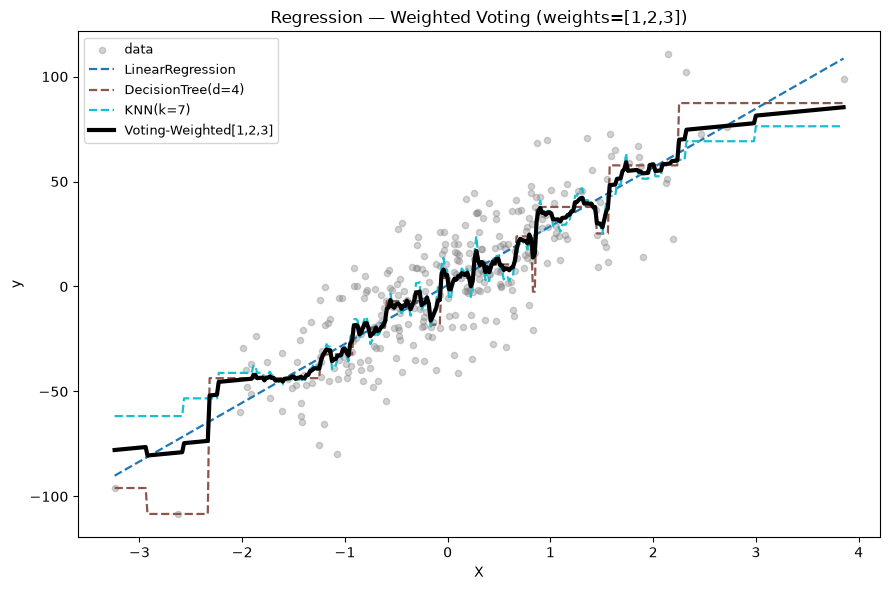

In [ ]:
# manually assigned weights
print("\n--- Scenario 3: WEIGHTED voting (weights=[1, 2, 3]) ---")
linr_w = LinearRegression()
dtr_w = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE)
knnr_w = KNeighborsRegressor(n_neighbors=7)

vote_reg_weighted = VotingRegressor(
    estimators=[("lr", linr_w), ("dt", dtr_w), ("knn", knnr_w)], weights=[1, 2, 3]
)

models_r3 = {
    "LinearRegression": linr_w,
    "DecisionTree(d=4)": dtr_w,
    "KNN(k=7)": knnr_w,
    "Voting-Weighted[1,2,3]": vote_reg_weighted,
}
evaluate_models_cv(models_r3, Xr, yr, scoring="r2")
plot_regression_lines(
    models_r3, Xr, yr,
    "Regression — Weighted Voting (weights=[1,2,3])",
    "reg_3_weighted.png", "Voting-Weighted[1,2,3]",
)